In [1209]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [1210]:
PROCESSED_DATA_DIR = Path("../data/processed")

In [1211]:
trainers_course_df = pd.read_csv(PROCESSED_DATA_DIR / "trainers_course.csv", sep=",", encoding="utf-8")

trainers_local_df = pd.read_csv(PROCESSED_DATA_DIR / "trainers_local.csv", sep=",", encoding="utf-8")

info_actions_df = pd.read_csv(PROCESSED_DATA_DIR / "info_actions.csv", sep=",", encoding="utf-8")

In [1212]:
workforce_df = trainers_course_df.merge(
    trainers_local_df, how="inner", on="trainer_id", validate="many_to_many"
)

workforce_df = workforce_df.merge(
    info_actions_df, how="inner", on="course_id", validate="many_to_one"
)

workforce_df = workforce_df.loc[workforce_df["active"]].drop_duplicates(subset=["trainer_id", "course_id", "local"])

workforce_df

,trainer_id,course_id,local,course_name,course_area,total_hours,active
0,1,CYB,Centro 4,Cibersegurança Básica,Informática,16,True
1,1,PBI,Centro 4,Power BI e Visualização de Dados,Informática,25,True
2,2,CYB,Centro 2,Cibersegurança Básica,Informática,16,True
3,2,PBI,Centro 2,Power BI e Visualização de Dados,Informática,25,True
4,3,GER,Centro 5,Geriatria e Apoio ao Idoso,Saúde,50,True
...,...,...,...,...,...,...,...
381,179,ING,Centro 5,Inglês Profissional,Línguas,30,True
382,180,VND,Centro 3,Vendas e Negociação,Comercial,16,True
383,181,SOC,Centro 2,Socorrismo Básico,Saúde e Segurança,16,True
384,182,HOT,Centro 4,Housekeeping e Operações Hoteleiras,Turismo,25,True


In [1213]:
total_trainers = workforce_df["trainer_id"].nunique()
total_courses = workforce_df["course_id"].nunique()
total_locals = workforce_df["local"].nunique()

print(f'Total trainers: {total_trainers}\nTotal courses: {total_courses}\nTotal locals: {total_locals}')

Total trainers: 183
Total courses: 24
Total locals: 5


In [1214]:
course_trainer_count = (
    workforce_df.groupby(["course_id", "course_name"])
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        diff_mean= lambda df: df["trainer_count"].sub(df["trainer_count"].mean()).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

course_trainer_count

,course_id,course_name,trainer_count,diff_mean
0,PBI,Power BI e Visualização de Dados,19,5.04
1,GER,Geriatria e Apoio ao Idoso,17,3.04
2,ING,Inglês Profissional,16,2.04
3,FOR,Formação Pedagógica Inicial de Formadores,16,2.04
4,CYB,Cibersegurança Básica,15,1.04
5,PRO,Gestão de Projetos,15,1.04
6,PRI,Primeiros Socorros,15,1.04
7,HAC,Higiene e Segurança Alimentar,15,1.04
8,EMP,Empilhadores e Movimentação de Cargas,14,0.04
9,LID,Liderança e Comunicação,14,0.04


In [1215]:
course_trainer_count.describe().round(2)

,trainer_count,diff_mean
count,24.00,24.00
mean,13.96,-0.00
std,1.85,1.85
min,11.00,-2.96
25%,13.00,-0.96
50%,14.00,0.04
75%,15.00,1.04
max,19.00,5.04


In [1216]:
local_trainer_count = (
    workforce_df.groupby("local")
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        pct_trainer= lambda df: df["trainer_count"].div(total_trainers).mul(100).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

local_trainer_count

,local,trainer_count,pct_trainer
0,Centro 2,44,24.04
1,Centro 3,44,24.04
2,Centro 5,41,22.40
3,Centro 1,39,21.31
4,Centro 4,39,21.31


In [1217]:
area_trainers_count = (
    workforce_df.groupby("course_area")
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .assign(
        pct_trainer= lambda df: df["trainer_count"].div(total_trainers).mul(100).round(2)
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

area_trainers_count

,course_area,trainer_count,pct_trainer
0,Segurança,36,19.67
1,Informática,33,18.03
2,Gestão,31,16.94
3,Alimentar,25,13.66
4,Saúde,25,13.66
5,Saúde e Segurança,24,13.11
6,Turismo,18,9.84
7,Formação,16,8.74
8,Línguas,16,8.74
9,Comercial,14,7.65


In [1218]:
course_local_trainers_count = (
    workforce_df.groupby(["course_id", "course_name", "local"])
    .agg(
        trainer_count=("trainer_id", "nunique")
    )
    .sort_values(by="trainer_count", ascending=False)
    .reset_index()
)

course_local_trainers_count.head(20)

,course_id,course_name,local,trainer_count
0,PBI,Power BI e Visualização de Dados,Centro 4,6
1,HAC,Higiene e Segurança Alimentar,Centro 2,5
2,HCP,HACCP Aplicado,Centro 1,4
3,ING,Inglês Profissional,Centro 2,4
4,SCI,Segurança Contra Incêndios,Centro 3,4
5,HAC,Higiene e Segurança Alimentar,Centro 5,4
6,PBI,Power BI e Visualização de Dados,Centro 2,4
7,HCP,HACCP Aplicado,Centro 2,4
8,HCP,HACCP Aplicado,Centro 3,4
9,PYT,Introdução à Programação em Python,Centro 5,4


In [1219]:
course_local_trainers_count.describe().round(2)

,trainer_count
count,120.00
mean,3.22
std,0.89
min,2.00
25%,2.00
50%,3.00
75%,4.00
max,6.00


In [1220]:
trainer_features = (
    workforce_df
    .groupby("trainer_id", as_index=False)
    .agg(
        course_count=("course_id", "nunique"),
        local_count=("local", "nunique"),
        area_count=("course_area", "nunique")
    )
    .assign(
        local_specialist=lambda df:
            df["course_count"].eq(1)
            & df["local_count"].eq(1),

        mobile_specialist=lambda df:
            df["course_count"].eq(1)
            & df["local_count"].gt(1),

        local_multicourse=lambda df:
            df["course_count"].gt(1)
            & df["local_count"].eq(1),

        mobile_multicourse=lambda df:
            df["course_count"].gt(1)
            & df["local_count"].gt(1)
    )
)

In [1221]:
workforce_enriched = workforce_df.merge(
    trainer_features[
        [
            "trainer_id",
            "course_count",
            "local_count",
            "area_count",
            "local_specialist",
            "mobile_specialist",
            "local_multicourse",
            "mobile_multicourse"
        ]
    ],
    on="trainer_id",
    how="left",
    validate="many_to_one"
)

In [1222]:
trainer_level = (
    workforce_enriched
    .drop_duplicates("trainer_id")
    .copy()
)

trainer_level["trainer_profile"] = "Unclassified"

trainer_level.loc[
    trainer_level["local_specialist"],
    "trainer_profile"
] = "Single-course Local"

trainer_level.loc[
    trainer_level["mobile_specialist"],
    "trainer_profile"
] = "Single-course Mobile"

trainer_level.loc[
    trainer_level["local_multicourse"],
    "trainer_profile"
] = "Multicourse Local"

trainer_level.loc[
    trainer_level["mobile_multicourse"],
    "trainer_profile"
] = "Multicourse Mobile"

trainer_level = trainer_level[["trainer_id", "course_count", "local_count", "area_count", "trainer_profile"]].reset_index(drop=True)

trainer_level

,trainer_id,course_count,local_count,area_count,trainer_profile
0,1,2,1,1,Multicourse Local
1,2,2,1,1,Multicourse Local
2,3,2,1,2,Multicourse Local
3,4,3,1,2,Multicourse Local
4,5,2,1,1,Multicourse Local
...,...,...,...,...,...
178,179,1,1,1,Single-course Local
179,180,1,1,1,Single-course Local
180,181,1,1,1,Single-course Local
181,182,1,1,1,Single-course Local


In [1223]:
course_local_workforce = (
    workforce_enriched
    .groupby(
        ["course_id", "course_name", "course_area", "local"],
        as_index=False
    )
    .agg(
        trainer_count=("trainer_id", "nunique"),

        local_specialist_count=("local_specialist", "sum"),

        mobile_specialist_count=(
            "mobile_specialist",
            "sum"
        ),

        local_multicourse_count=(
            "local_multicourse",
            "sum"
        ),

        mobile_multicourse_count=("mobile_multicourse", "sum"),

        avg_courses_per_trainer=("course_count", "mean"),
        avg_locations_per_trainer=("local_count", "mean")
    )
    .assign(
        avg_courses_per_trainer=lambda df: df["avg_courses_per_trainer"].round(1),
        avg_locations_per_trainer=lambda df: df["avg_locations_per_trainer"].round(1)
    )
)

course_local_workforce

,course_id,course_name,course_area,local,trainer_count,local_specialist_count,mobile_specialist_count,local_multicourse_count,mobile_multicourse_count,avg_courses_per_trainer,avg_locations_per_trainer
0,CYB,Cibersegurança Básica,Informática,Centro 1,3,0,0,1,2,2.3,1.7
1,CYB,Cibersegurança Básica,Informática,Centro 2,3,1,0,2,0,1.7,1.0
2,CYB,Cibersegurança Básica,Informática,Centro 3,4,0,0,2,2,2.5,1.5
3,CYB,Cibersegurança Básica,Informática,Centro 4,4,0,0,3,1,2.0,1.2
4,CYB,Cibersegurança Básica,Informática,Centro 5,4,0,0,3,1,2.5,1.2
...,...,...,...,...,...,...,...,...,...,...,...
115,VND,Vendas e Negociação,Comercial,Centro 1,4,1,0,1,2,2.0,1.5
116,VND,Vendas e Negociação,Comercial,Centro 2,4,0,0,3,1,2.2,1.2
117,VND,Vendas e Negociação,Comercial,Centro 3,4,1,0,2,1,2.2,1.2
118,VND,Vendas e Negociação,Comercial,Centro 4,2,0,0,2,0,2.5,1.0


In [1224]:
profile_count = (
    course_local_workforce[
        [
            "local_specialist_count",
            "mobile_specialist_count",
            "local_multicourse_count",
            "mobile_multicourse_count"
        ]
    ]
    .sum(axis=1)
)

assert profile_count.eq(
    course_local_workforce["trainer_count"]
).all()

In [1225]:
def plot_workforce_profiles(df, charts, subtitle, ylabel, nrows=2, ncols=2, figsize=(13, 9)):
    
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, facecolor="#E9ECEF", squeeze=False)

    fig.suptitle(subtitle, fontsize=16, fontweight="bold")

    for ax, (column, (title, description)) in zip(axes.flat, charts.items()):
        
        frequency_distribution = (
            df[column]
            .value_counts()
            .sort_index()
        )

        positions = range(len(frequency_distribution))
        categories = frequency_distribution.index.astype(str)

        bars = ax.bar(positions, frequency_distribution.values)

        labels = [
            f"{value}\n({value / frequency_distribution.sum():.1%})"
            for value in frequency_distribution.values
        ]

        ax.bar_label(bars, labels=labels, padding=4)

        ax.set_facecolor("#FFFFFF")

        ax.set_title(title, loc="left", fontweight="bold", pad=25)

        ax.text(
            0,
            1.02,
            description,
            transform=ax.transAxes,
            fontsize=9,
            color="#6B7280"
        )

        ax.set_ylabel(ylabel)
        ax.set_ylim(0, frequency_distribution.max() * 1.2)

        ax.set_xticks(positions, categories)

    for ax in axes.flat[len(charts):]:
        ax.remove()

    plt.tight_layout(rect=[0, 0, 1, 0.95],h_pad=3)

    plt.show()

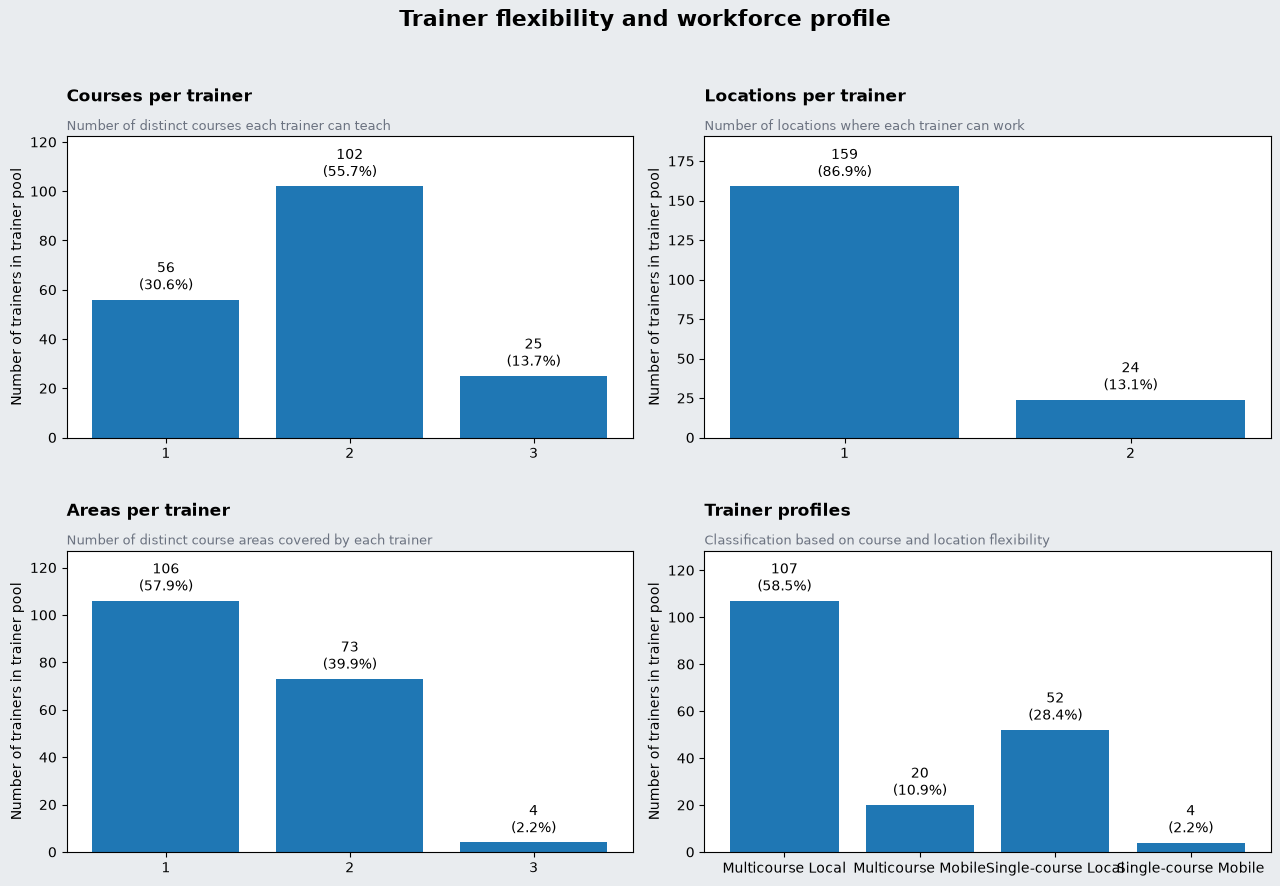

In [1226]:
trainer_profile_charts = {
    "course_count": (
        "Courses per trainer",
        "Number of distinct courses each trainer can teach"
    ),
    "local_count": (
        "Locations per trainer",
        "Number of locations where each trainer can work"
    ),
    "area_count": (
        "Areas per trainer",
        "Number of distinct course areas covered by each trainer"
    ),
    "trainer_profile": (
        "Trainer profiles",
        "Classification based on course and location flexibility"
    )
}

plot_workforce_profiles(
    trainer_level,
    trainer_profile_charts,
    "Trainer flexibility and workforce profile",
    "Number of trainers in trainer pool",
    2,
    2
)

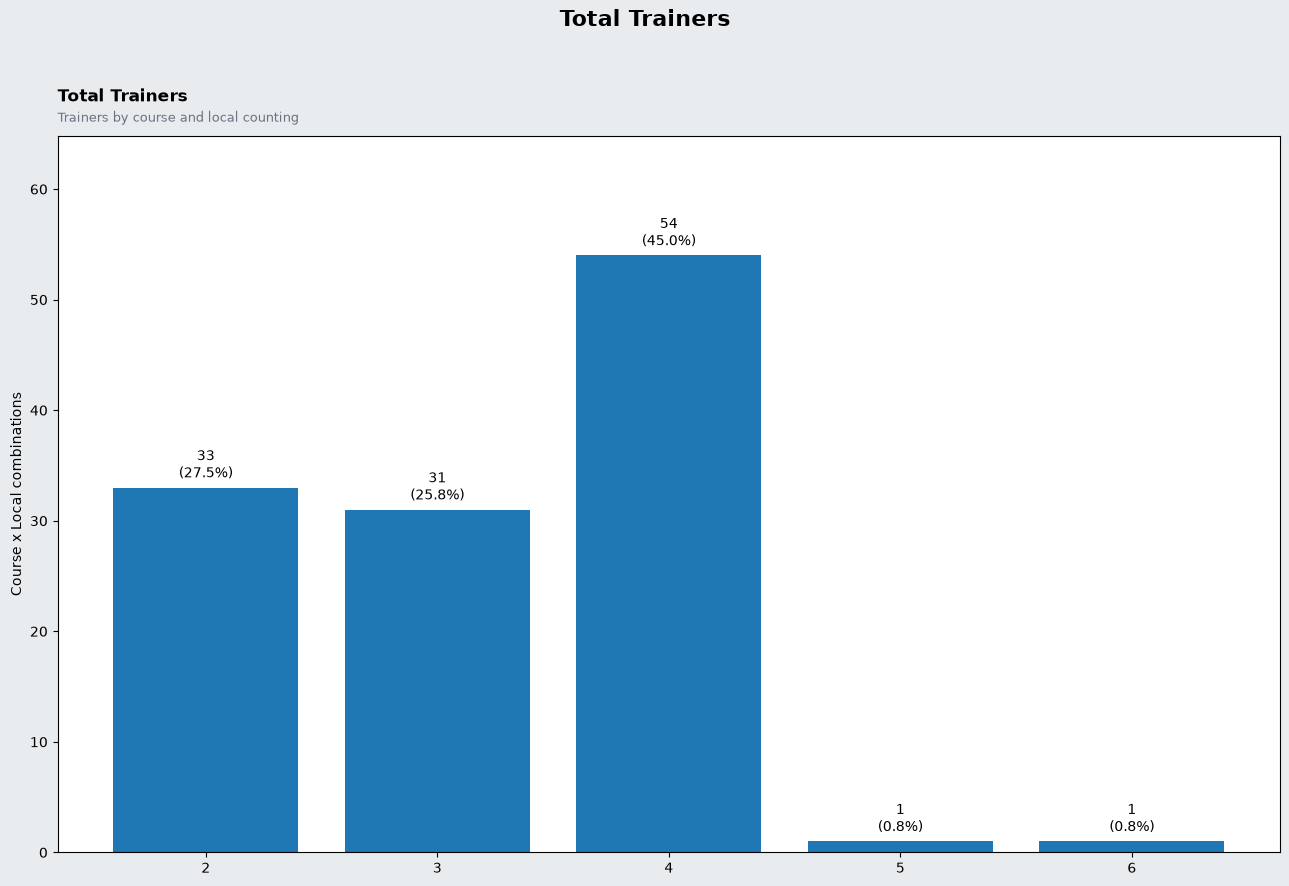

In [1227]:
trainer_count_chart = {
    "trainer_count": (
        "Total Trainers", 
        "Trainers by course and local counting"
    )
}

plot_workforce_profiles(course_local_workforce, trainer_count_chart, "Total Trainers", "Course x Local combinations", 1, 1)

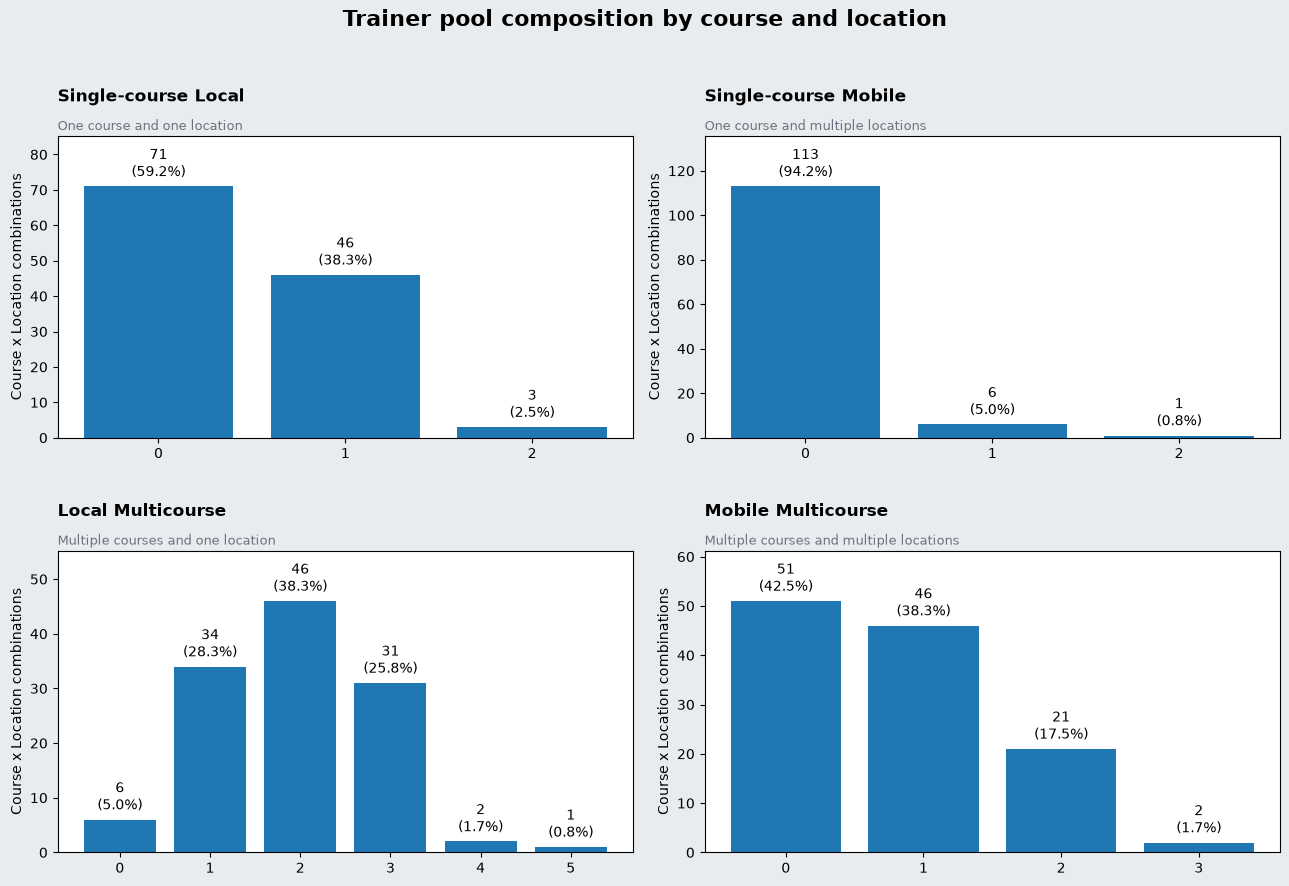

In [1228]:
availability_charts = {
    "local_specialist_count": (
        "Single-course Local",
        "One course and one location"
    ),
    "mobile_specialist_count": (
        "Single-course Mobile",
        "One course and multiple locations"
    ),
    "local_multicourse_count": (
        "Local Multicourse",
        "Multiple courses and one location"
    ),
    "mobile_multicourse_count": (
        "Mobile Multicourse",
        "Multiple courses and multiple locations"
    )
}

plot_workforce_profiles(course_local_workforce, availability_charts, "Trainer pool composition by course and location", "Course x Location combinations")

In [1229]:
course_local_workforce = (
    course_local_workforce
    .assign(
        backup_trainer_count=lambda df:
            df["trainer_count"].sub(1).clip(lower=0),

        single_trainer_dependency=lambda df:
            df["trainer_count"].eq(1),

        low_redundancy=lambda df:
            df["trainer_count"].le(2),

        mobile_backup_count=lambda df:
            df["mobile_specialist_count"]
            .add(df["mobile_multicourse_count"]),

        shared_trainer_count=lambda df:
            df["local_multicourse_count"]
            .add(df["mobile_multicourse_count"]),

        pct_shared_trainers=lambda df:
            df["shared_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(2)
    )
)

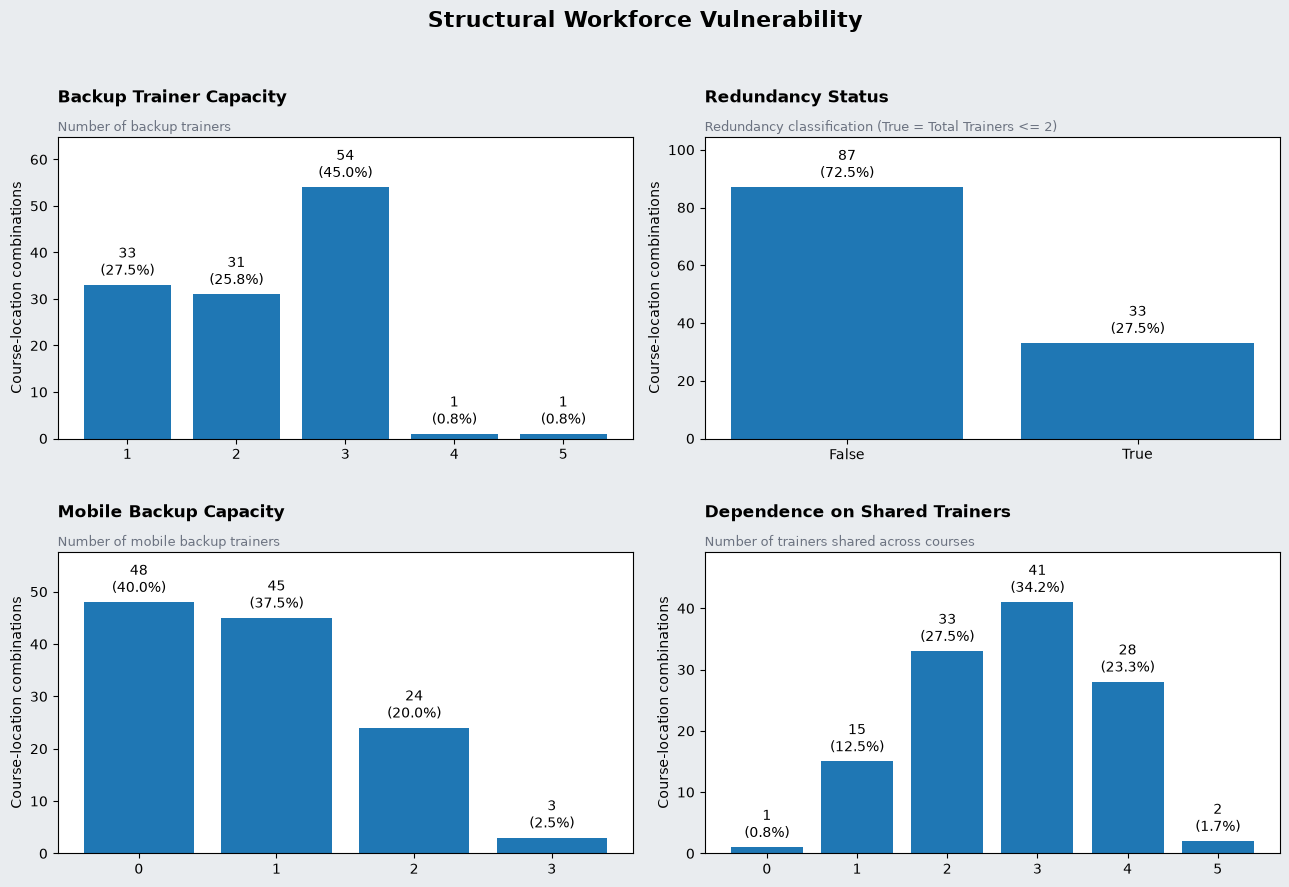

In [1230]:
vulnerability_charts = {
    "backup_trainer_count": (
        "Backup Trainer Capacity",
        "Number of backup trainers"
    ),

    "low_redundancy": (
        "Redundancy Status",
        "Redundancy classification (True = Total Trainers <= 2)"
    ),

    "mobile_backup_count": (
        "Mobile Backup Capacity",
        "Number of mobile backup trainers"
    ),

    "shared_trainer_count": (
        "Dependence on Shared Trainers",
        "Number of trainers shared across courses"
    )
}

plot_workforce_profiles(
    df=course_local_workforce,
    charts=vulnerability_charts,
    subtitle="Structural Workforce Vulnerability",
    ylabel="Course-location combinations",
    nrows=2,
    ncols=2
)

In [1231]:
def plot_heatmap(
    df,
    index,
    columns,
    values,
    title,
    xlabel,
    ylabel,
    colorbar_label,
    figsize=(12, 10),
    x_label_pad=15,
    y_label_pad=20,
    x_tick_pad=8,
    y_tick_pad=8
):
    heatmap_matrix = (
        df.pivot(
            index=index,
            columns=columns,
            values=values
        )
    )

    fig, ax = plt.subplots(
        figsize=figsize,
        facecolor="#E9ECEF"
    )

    heatmap = ax.imshow(
        heatmap_matrix.values,
        aspect="auto"
    )

    ax.set_xticks(
        range(len(heatmap_matrix.columns)),
        labels=heatmap_matrix.columns
    )

    ax.set_yticks(
        range(len(heatmap_matrix.index)),
        labels=heatmap_matrix.index
    )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=20
    )

    ax.set_xlabel(
        xlabel,
        labelpad=x_label_pad
    )

    ax.set_ylabel(
        ylabel,
        labelpad=y_label_pad
    )

    ax.tick_params(
        axis="x",
        pad=x_tick_pad
    )

    ax.tick_params(
        axis="y",
        pad=y_tick_pad
    )

    for row_index in range(heatmap_matrix.shape[0]):
        for column_index in range(heatmap_matrix.shape[1]):

            value = heatmap_matrix.iloc[
                row_index,
                column_index
            ]

            ax.text(
                column_index,
                row_index,
                f"{value:.0f}",
                ha="center",
                va="center"
            )

    colorbar = fig.colorbar(
        heatmap,
        ax=ax
    )

    colorbar.set_label(
        colorbar_label,
        labelpad=12
    )

    plt.tight_layout()
    plt.show()

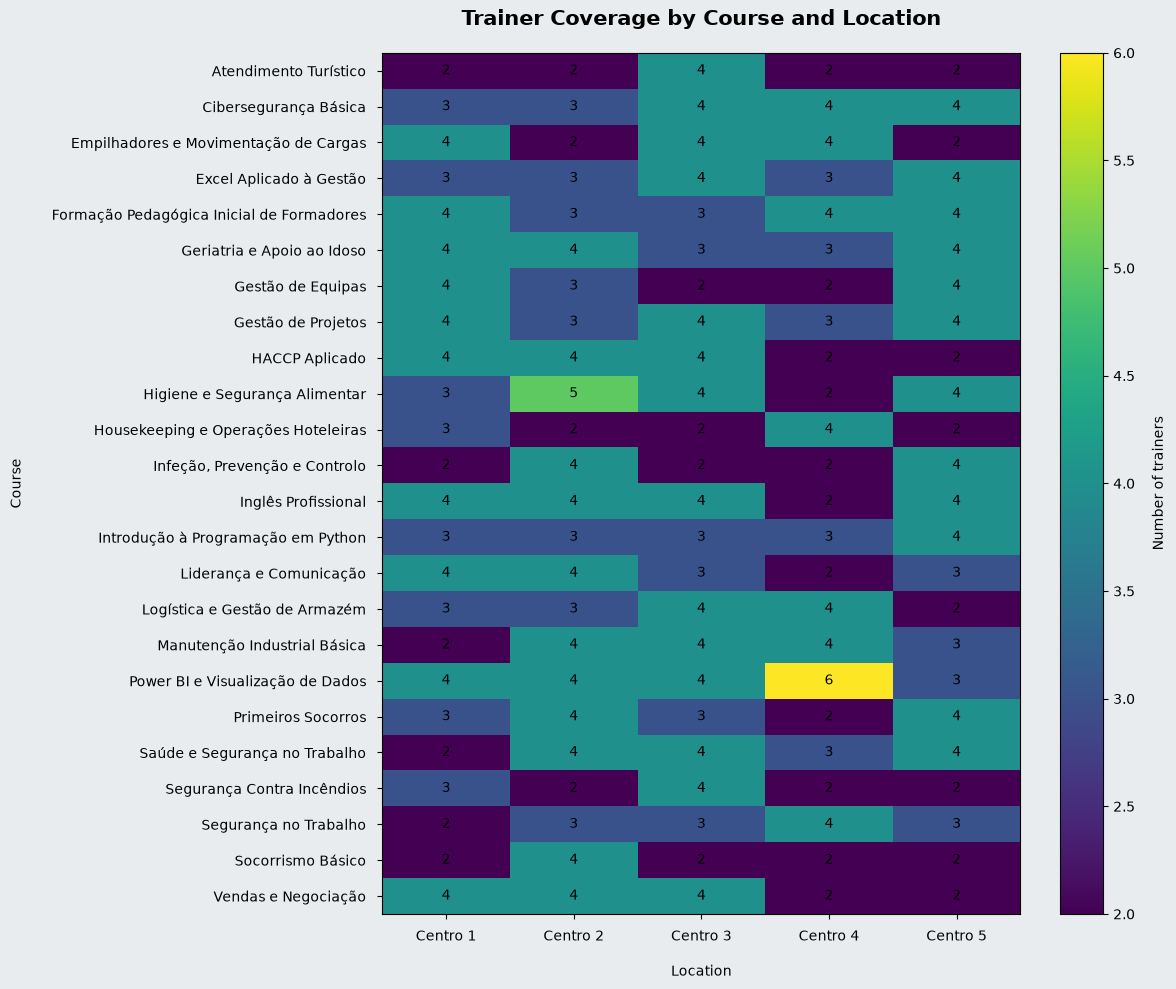

In [1232]:
plot_heatmap(
    df=course_local_workforce,
    index="course_name",
    columns="local",
    values="trainer_count",
    title="Trainer Coverage by Course and Location",
    xlabel="Location",
    ylabel="Course",
    colorbar_label="Number of trainers"
)

In [1233]:
WORKFORCE_SCORE_WEIGHTS = {
    "relative_scarcity": 0.50,
    "course_sharing": 0.25,
    "location_sharing": 0.25
}

WORKFORCE_FEATURE_COLUMNS = [
    "course_id",
    "course_name",
    "course_area",
    "local",

    "trainer_count",
    "pct_multicourse_trainers",
    "pct_mobile_trainers",

    "relative_scarcity_score",
    "course_sharing_score",
    "location_sharing_score",

    "relative_scarcity_contribution",
    "course_sharing_contribution",
    "location_sharing_contribution",

    "workforce_base_score",
    "workforce_score_percentile",
    "workforce_vulnerability_tier",
    "workforce_main_risk_driver",
    "workforce_base_priority_rank"
]

In [1234]:
workforce_features_df = (
    course_local_workforce
    .assign(
        multicourse_trainer_count=lambda df:
            df["local_multicourse_count"]
            .add(df["mobile_multicourse_count"]),

        mobile_trainer_count=lambda df:
            df["mobile_specialist_count"]
            .add(df["mobile_multicourse_count"])
    )
    .assign(
        pct_multicourse_trainers=lambda df:
            df["multicourse_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(1),

        pct_mobile_trainers=lambda df:
            df["mobile_trainer_count"]
            .div(df["trainer_count"])
            .mul(100)
            .round(1)
    )
)

workforce_features_df.head()

,course_id,course_name,course_area,local,trainer_count,local_specialist_count,mobile_specialist_count,local_multicourse_count,mobile_multicourse_count,avg_courses_per_trainer,...,backup_trainer_count,single_trainer_dependency,low_redundancy,mobile_backup_count,shared_trainer_count,pct_shared_trainers,multicourse_trainer_count,mobile_trainer_count,pct_multicourse_trainers,pct_mobile_trainers
0,CYB,Cibersegurança Básica,Informática,Centro 1,3,0,0,1,2,2.3,...,2,False,False,2,3,100.00,3,2,100.0,66.7
1,CYB,Cibersegurança Básica,Informática,Centro 2,3,1,0,2,0,1.7,...,2,False,False,0,2,66.67,2,0,66.7,0.0
2,CYB,Cibersegurança Básica,Informática,Centro 3,4,0,0,2,2,2.5,...,3,False,False,2,4,100.00,4,2,100.0,50.0
3,CYB,Cibersegurança Básica,Informática,Centro 4,4,0,0,3,1,2.0,...,3,False,False,1,4,100.00,4,1,100.0,25.0
4,CYB,Cibersegurança Básica,Informática,Centro 5,4,0,0,3,1,2.5,...,3,False,False,1,4,100.00,4,1,100.0,25.0


In [1235]:
workforce_features_df = (
    workforce_features_df
    .assign(
        relative_scarcity_score=lambda df:
            df["trainer_count"]
            .rank(
                method="average",
                pct=True,
                ascending=False
            )
            .mul(100)
            .round(1),

        course_sharing_score=lambda df:
            df["pct_multicourse_trainers"],

        location_sharing_score=lambda df:
            df["pct_mobile_trainers"]
    )
)

workforce_features_df[
    [
        "trainer_count",
        "relative_scarcity_score",
        "course_sharing_score",
        "location_sharing_score"
    ]
].head()

,trainer_count,relative_scarcity_score,course_sharing_score,location_sharing_score
0,3,60.0,100.0,66.7
1,3,60.0,66.7,0.0
2,4,24.6,100.0,50.0
3,4,24.6,100.0,25.0
4,4,24.6,100.0,25.0


In [1236]:
workforce_features_df = (
    workforce_features_df
    .assign(
        relative_scarcity_contribution=lambda df:
            df["relative_scarcity_score"]
            .mul(WORKFORCE_SCORE_WEIGHTS["relative_scarcity"])
            .round(1),

        course_sharing_contribution=lambda df:
            df["course_sharing_score"]
            .mul(WORKFORCE_SCORE_WEIGHTS["course_sharing"])
            .round(1),

        location_sharing_contribution=lambda df:
            df["location_sharing_score"]
            .mul(WORKFORCE_SCORE_WEIGHTS["location_sharing"])
            .round(1)
    )
    .assign(
        workforce_base_score=lambda df:
            (
                df["relative_scarcity_contribution"]
                .add(df["course_sharing_contribution"])
                .add(df["location_sharing_contribution"])
            )
            .round(1)
    )
)

workforce_features_df[
    [
        "relative_scarcity_contribution",
        "course_sharing_contribution",
        "location_sharing_contribution",
        "workforce_base_score"
    ]
].head()

,relative_scarcity_contribution,course_sharing_contribution,location_sharing_contribution,workforce_base_score
0,30.0,25.0,16.7,71.7
1,30.0,16.7,0.0,46.7
2,12.3,25.0,12.5,49.8
3,12.3,25.0,6.2,43.5
4,12.3,25.0,6.2,43.5


In [1237]:
workforce_features_df = (
    workforce_features_df
    .assign(
        workforce_score_percentile=lambda df:
            df["workforce_base_score"]
            .rank(
                method="average",
                pct=True,
                ascending=True
            )
            .mul(100)
            .round(1)
    )
    .assign(
        workforce_vulnerability_tier=lambda df:
            pd.cut(
                df["workforce_score_percentile"],
                bins=[0, 25, 50, 75, 100],
                labels=[
                    "Low",
                    "Lower-middle",
                    "Upper-middle",
                    "High"
                ],
                include_lowest=True
            ),

        workforce_main_risk_driver=lambda df:
            df[
                [
                    "relative_scarcity_contribution",
                    "course_sharing_contribution",
                    "location_sharing_contribution"
                ]
            ]
            .idxmax(axis=1)
            .map(
                {
                    "relative_scarcity_contribution":
                        "Trainer scarcity",

                    "course_sharing_contribution":
                        "Multicourse trainers",

                    "location_sharing_contribution":
                        "Mobile trainers"
                }
            )
    )
    .sort_values(
        by="workforce_base_score",
        ascending=False
    )
    .reset_index(drop=True)
    .assign(
        workforce_base_priority_rank=lambda df:
            df.index + 1
    )
    .loc[:, WORKFORCE_FEATURE_COLUMNS]
)

workforce_features_df

,course_id,course_name,course_area,local,trainer_count,pct_multicourse_trainers,pct_mobile_trainers,relative_scarcity_score,course_sharing_score,location_sharing_score,relative_scarcity_contribution,course_sharing_contribution,location_sharing_contribution,workforce_base_score,workforce_score_percentile,workforce_vulnerability_tier,workforce_main_risk_driver,workforce_base_priority_rank
0,TUR,Atendimento Turístico,Turismo,Centro 4,2,100.0,50.0,86.7,100.0,50.0,43.4,25.0,12.5,80.9,97.9,High,Trainer scarcity,1
1,HOT,Housekeeping e Operações Hoteleiras,Turismo,Centro 3,2,100.0,50.0,86.7,100.0,50.0,43.4,25.0,12.5,80.9,97.9,High,Trainer scarcity,2
2,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 2,2,100.0,50.0,86.7,100.0,50.0,43.4,25.0,12.5,80.9,97.9,High,Trainer scarcity,3
3,SST,Saúde e Segurança no Trabalho,Segurança,Centro 1,2,100.0,50.0,86.7,100.0,50.0,43.4,25.0,12.5,80.9,97.9,High,Trainer scarcity,4
4,ING,Inglês Profissional,Línguas,Centro 4,2,100.0,50.0,86.7,100.0,50.0,43.4,25.0,12.5,80.9,97.9,High,Trainer scarcity,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,EMP,Empilhadores e Movimentação de Cargas,Segurança,Centro 3,4,75.0,0.0,24.6,75.0,0.0,12.3,18.8,0.0,31.1,5.0,Low,Multicourse trainers,116
116,GER,Geriatria e Apoio ao Idoso,Saúde,Centro 5,4,75.0,0.0,24.6,75.0,0.0,12.3,18.8,0.0,31.1,5.0,Low,Multicourse trainers,117
117,INF,"Infeção, Prevenção e Controlo",Saúde,Centro 2,4,50.0,25.0,24.6,50.0,25.0,12.3,12.5,6.2,31.0,2.5,Low,Multicourse trainers,118
118,HAC,Higiene e Segurança Alimentar,Alimentar,Centro 5,4,50.0,0.0,24.6,50.0,0.0,12.3,12.5,0.0,24.8,1.7,Low,Multicourse trainers,119


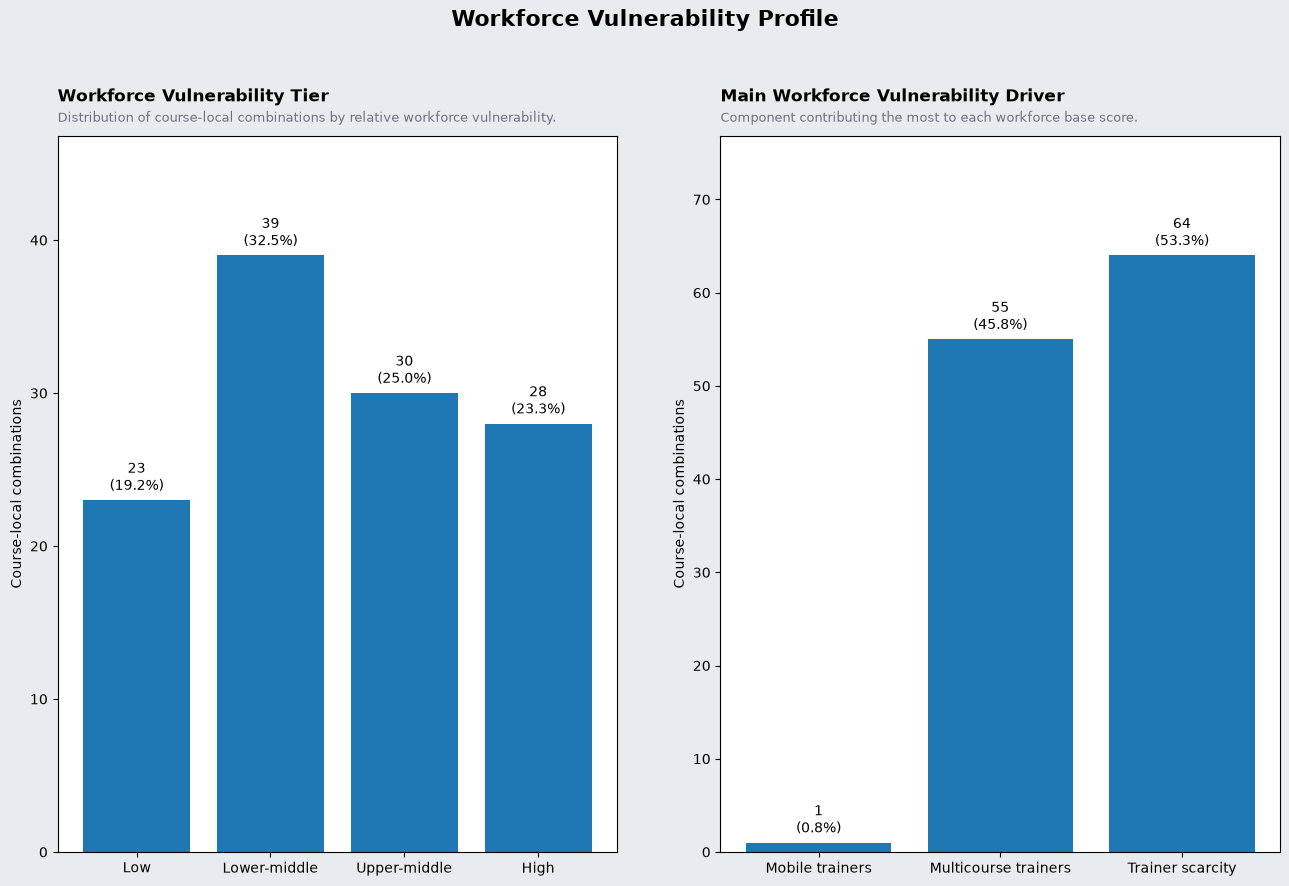

In [1238]:
scores_charts = {
    "workforce_vulnerability_tier": (
        "Workforce Vulnerability Tier",
        "Distribution of course-local combinations by relative workforce vulnerability."
    ),

    "workforce_main_risk_driver": (
        "Main Workforce Vulnerability Driver",
        "Component contributing the most to each workforce base score."
    )
}

plot_workforce_profiles(
    df=workforce_features_df,
    charts=scores_charts,
    subtitle="Workforce Vulnerability Profile",
    ylabel="Course-local combinations",
    nrows=1,
    ncols=2
)

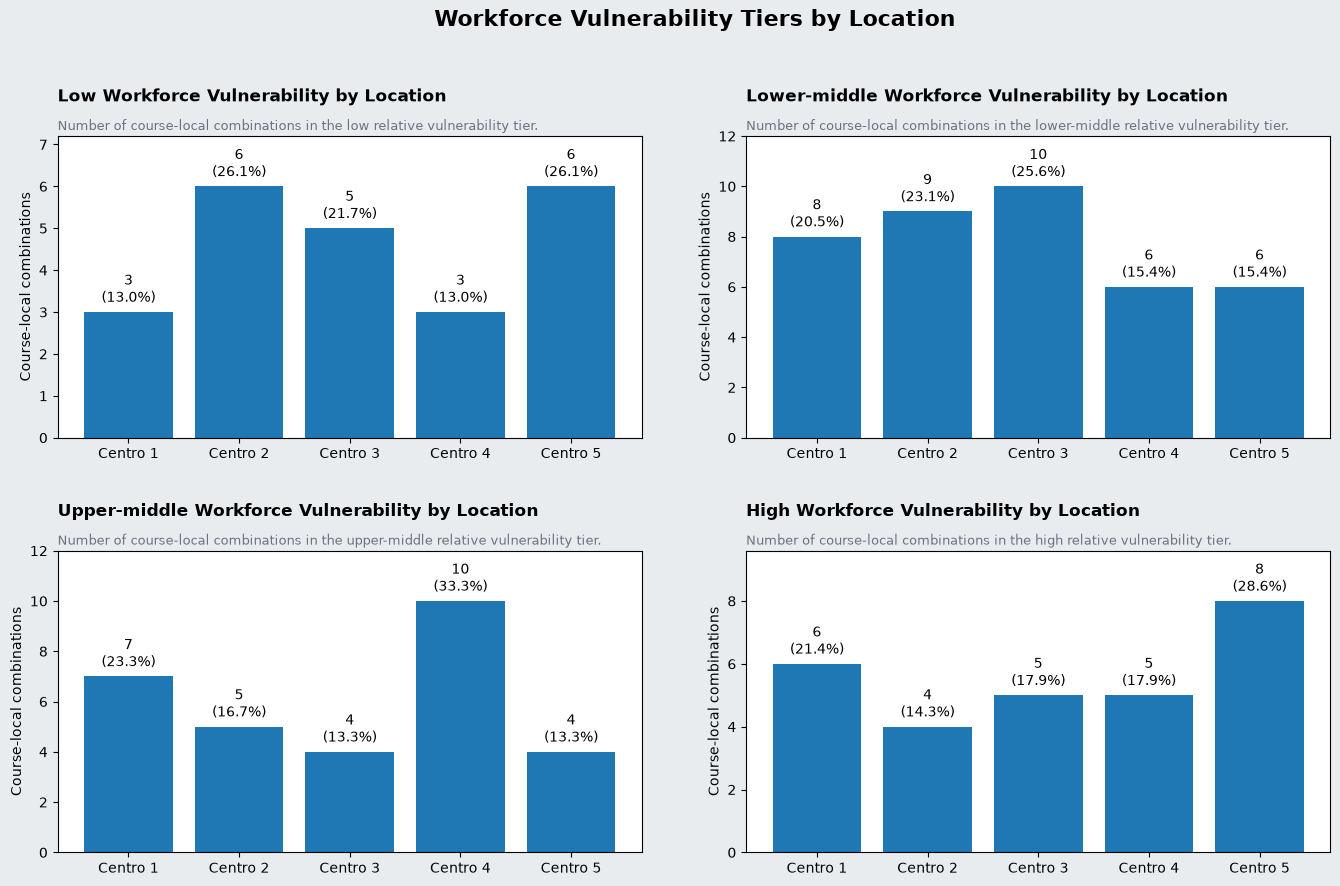

In [1239]:
vulnerability_tiers = [
    "Low",
    "Lower-middle",
    "Upper-middle",
    "High"
]

workforce_location_tier_df = pd.concat(
    {
        f"{tier.lower()}_local": (
            workforce_features_df
            .loc[
                workforce_features_df["workforce_vulnerability_tier"]
                .eq(tier),
                "local"
            ]
            .reset_index(drop=True)
        )
        for tier in vulnerability_tiers
    },
    axis=1
)

local_tier_charts = {
    f"{tier.lower()}_local": (
        f"{tier} Workforce Vulnerability by Location",
        f"Number of course-local combinations in the {tier.lower()} relative vulnerability tier."
    )
    for tier in vulnerability_tiers
}

plot_workforce_profiles(
    df=workforce_location_tier_df,
    charts=local_tier_charts,
    subtitle="Workforce Vulnerability Tiers by Location",
    ylabel="Course-local combinations",
    nrows=2,
    ncols=2,
    figsize=(14,9)
)

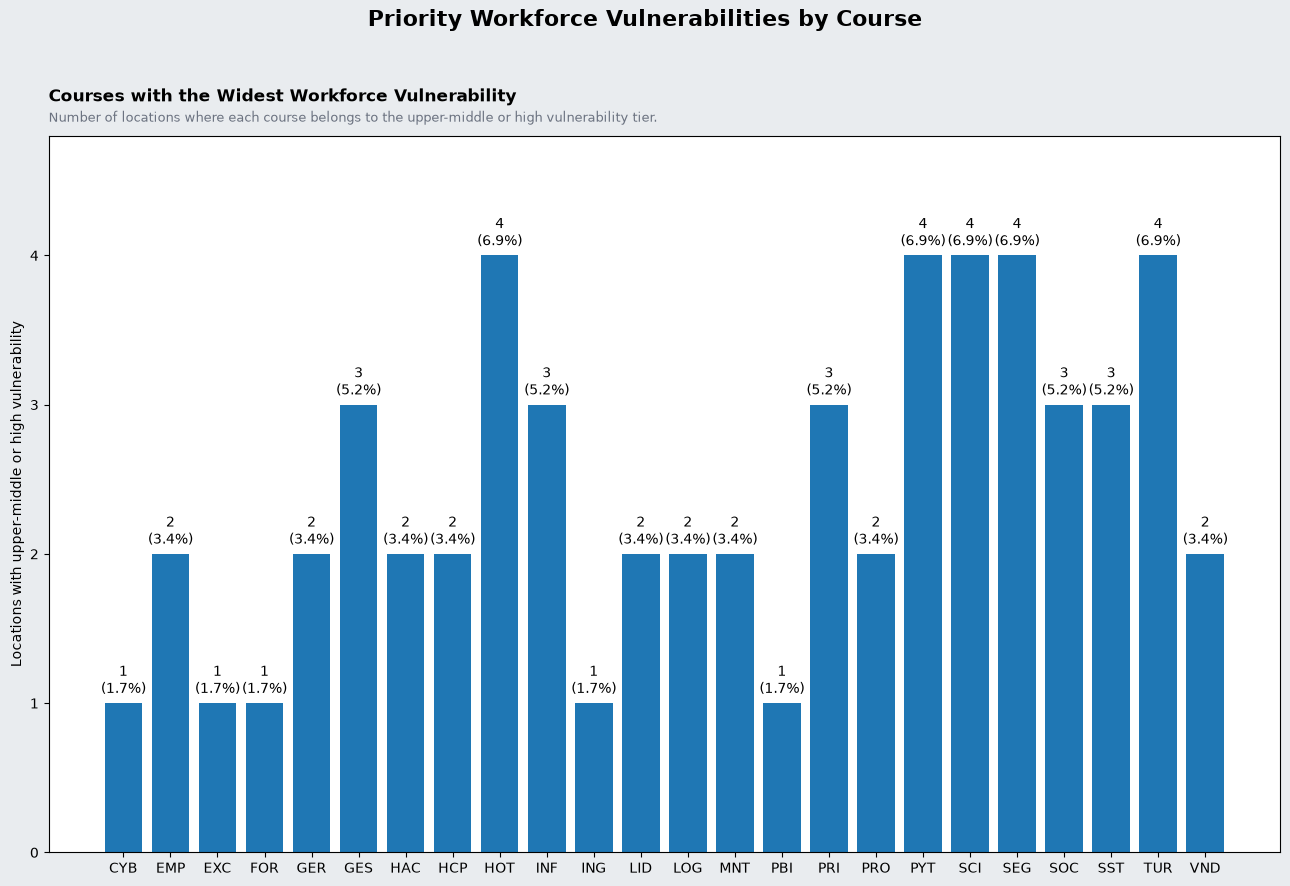

In [1240]:
priority_courses_df = (
    workforce_features_df
    .loc[
        workforce_features_df["workforce_vulnerability_tier"]
        .isin(["Upper-middle", "High"]),
        ["course_id"]
    ]
    .copy()
)

course_vulnerability_charts = {
    "course_id": (
        "Courses with the Widest Workforce Vulnerability",
        "Number of locations where each course belongs to the upper-middle or high vulnerability tier."
    )
}

plot_workforce_profiles(
    df=priority_courses_df,
    charts=course_vulnerability_charts,
    subtitle="Priority Workforce Vulnerabilities by Course",
    ylabel="Locations with upper-middle or high vulnerability",
    nrows=1,
    ncols=1
)